# 09 · Geoprivacy, aggregation, and authenticated encryption

**Decision question.** What information should we share, and what does encryption protect after that decision?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib', 'cryptography'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Different controls answer different questions

Encryption protects a payload from readers without the key. Aggregation changes the precision of what is
shared. Masking perturbs positions. None alone establishes anonymity, authorization, or ethical acceptability.
The supplied map-encryption presentation emphasizes all of these layers, including keys, metadata, and exports.

![Minimize, aggregate, encrypt, review](assets/privacy-layers.svg)

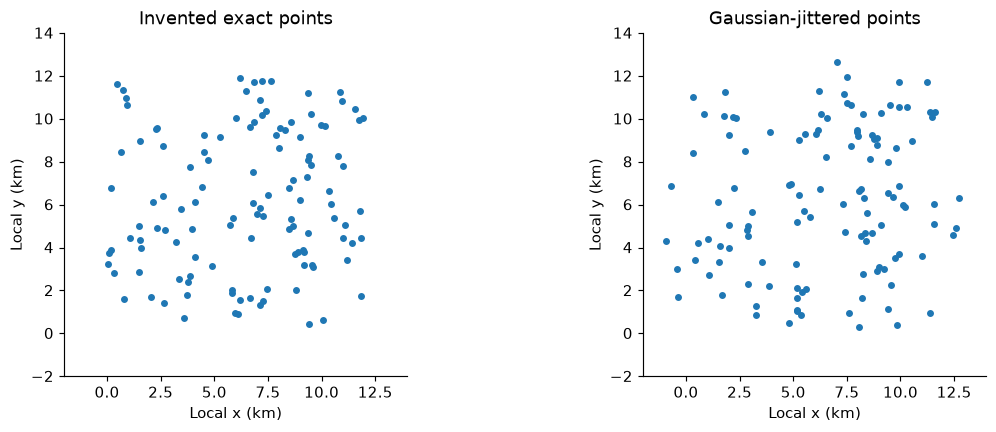

In [2]:
rng=np.random.default_rng(9)
points=pd.DataFrame({'x_km':rng.uniform(0,12,120),'y_km':rng.uniform(0,12,120)})
masked=points+rng.normal(0,.65,points.shape)
fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,p,title in zip(axes,[points,masked],['Invented exact points','Gaussian-jittered points']):
    ax.scatter(p.x_km,p.y_km,s=14); ax.set(xlabel='Local x (km)',ylabel='Local y (km)',title=title,aspect='equal',xlim=(-2,14),ylim=(-2,14))
plt.show()

## Measure a masking tradeoff, without promising anonymity

Compare nearest-facility distances before and after perturbation. Changing locations can affect access
inferences, while auxiliary information may still make a record linkable. Clipping points at a boundary
can introduce additional spatial bias. These invented points have no identities or real addresses.

In [3]:
facility=np.array([6,6])
before=np.linalg.norm(points.to_numpy()-facility,axis=1)
after=np.linalg.norm(masked.to_numpy()-facility,axis=1)
print('Mean absolute access-distance distortion (km):',round(float(np.abs(before-after).mean()),3))
print('Share crossing an arbitrary 4-km boundary:',round(float(np.mean((before<=4)!=(after<=4))),3))

Mean absolute access-distance distortion (km): 0.49
Share crossing an arbitrary 4-km boundary: 0.117


## Aggregate, suppress, and inspect utility

Count points in fixed bins, and hide counts below a chosen threshold. This is a simple display rule,
not a proof of k-anonymity or differential privacy. Other maps, totals, and overlapping releases can reveal
suppressed values. Blank bins below represent suppressed counts, including zeros; document that choice.

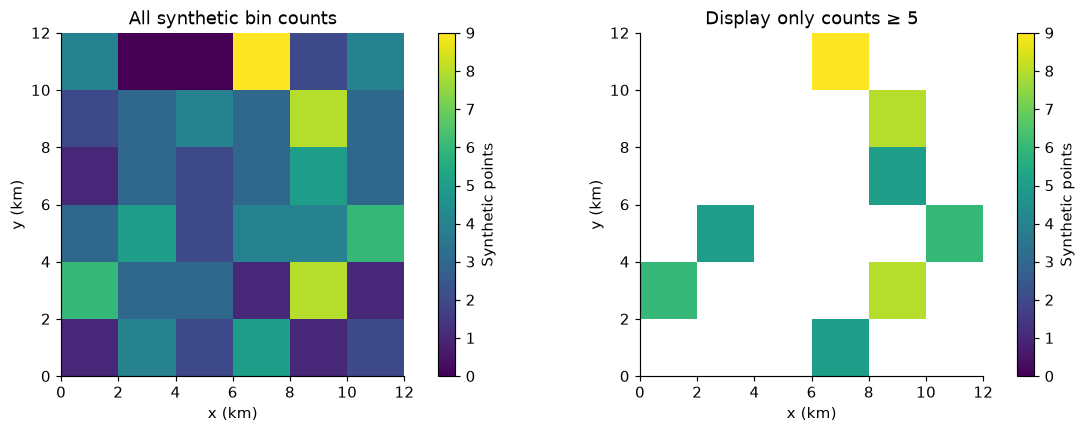

Fraction of synthetic points in displayed bins: 0.433


In [4]:
edges=np.arange(0,13,2)
counts,_,_=np.histogram2d(points.y_km,points.x_km,bins=[edges,edges])
threshold=5
shared=np.where(counts>=threshold,counts,np.nan)
fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,z,title in zip(axes,[counts,shared],['All synthetic bin counts',f'Display only counts ≥ {threshold}']):
    im=ax.imshow(z,origin='lower',extent=[0,12,0,12],vmin=0,vmax=counts.max())
    ax.set(xlabel='x (km)',ylabel='y (km)',title=title); fig.colorbar(im,ax=ax,label='Synthetic points')
plt.show()
print('Fraction of synthetic points in displayed bins:',round(float(np.nansum(shared)/counts.sum()),3))

## Real authenticated encryption, with a temporary teaching key

AES-GCM provides confidentiality and authentication. This cell generates a fresh 256-bit key and a fresh
96-bit nonce, encrypts the synthetic JSON, and verifies a round trip. Never reuse a nonce with the same key.
The key remains in kernel memory and is never printed or exported. Rerunning creates a new key; this is
an illustration, not durable key management, secure deletion, or a production security boundary.

In [5]:
import os, base64
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.exceptions import InvalidTag
payload=json.dumps({'data_status':'synthetic','points':points.round(4).to_dict('records')},sort_keys=True).encode()
key=AESGCM.generate_key(bit_length=256)
nonce=os.urandom(12)
aad=b'rewiring-synthetic-points:v1'
cipher=AESGCM(key)
ciphertext=cipher.encrypt(nonce,payload,aad)
decoded=cipher.decrypt(nonce,ciphertext,aad)
assert decoded==payload
print('Round trip verified | plaintext bytes:',len(payload),'| ciphertext bytes:',len(ciphertext))
print('Key and plaintext have not been printed.')

Round trip verified | plaintext bytes: 4127 | ciphertext bytes: 4143
Key and plaintext have not been printed.


## Fail closed if the payload or key changes

An authenticated cipher must reject tampering. A successful round trip alone would not test that property.
Do not catch an integrity failure and silently fall back to plaintext. Metadata and screenshots can still
leak information even when the payload is encrypted.

In [6]:
tampered=bytearray(ciphertext); tampered[0]^=1
for label,test_cipher,test_payload in [('tampered payload',cipher,bytes(tampered)),
                                      ('wrong key',AESGCM(AESGCM.generate_key(bit_length=256)),ciphertext)]:
    try:
        test_cipher.decrypt(nonce,test_payload,aad)
    except InvalidTag:
        print(label,': rejected as expected')
    else:
        raise AssertionError('Authentication failure was not detected')
envelope={'schema_version':1,'algorithm':'AES-256-GCM','data_status':'synthetic',
          'nonce_b64':base64.b64encode(nonce).decode(), 'aad':aad.decode(),
          'ciphertext_b64':base64.b64encode(ciphertext).decode()}
print(save_export('encrypted-synthetic-layer.json',envelope))
# The envelope cannot be recovered after the session key is lost; no key file is written.

tampered payload : rejected as expected
wrong key : rejected as expected
exports\encrypted-synthetic-layer.json


## Review the complete release

The lowest-risk option may be not collecting precise coordinates in the first place. Separate collection,
analysis, sharing, and deletion decisions. For a real protected workflow, use organizational governance,
access control, key rotation/revocation, audit, and a reviewed threat model. A public static website does
not supply those controls merely because its Python executes locally.

In [7]:
threats=pd.DataFrame({'threat':['raw file disclosure','small-area linkage','browser compromise','misleading public map'],
 'control':['minimize and encrypt','review aggregation and related releases','approved environment and access controls','label uncertainty and consult affected communities'],
 'remaining_limit':['key access reveals plaintext','aggregation is not an anonymity guarantee','client memory is not a secure enclave','a correct calculation can still stigmatize']})
display(threats)

,threat,control,remaining_limit
0,raw file disclosure,minimize and encrypt,key access reveals plaintext
1,small-area linkage,review aggregation and related releases,aggregation is not an anonymity guarantee
2,browser compromise,approved environment and access controls,client memory is not a secure enclave
3,misleading public map,label uncertainty and consult affected communi...,a correct calculation can still stigmatize


## Investigate, interpret, and discuss

1. Compare thresholds 3, 5, and 8. How much utility is lost, and what disclosure risks remain?
2. Alter the associated data (`aad`) and confirm decryption fails.
3. Design a key-distribution and revocation process without putting keys in a notebook, URL, or repository.
4. Explain why encryption does not make a published precise map private after decryption.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- Tolentino, H., Tobias, J. L., Wuhib, T., & Mishra, V. (2026), *Map Encryption Democratized with JupyterLite*, supplied presentation, pp. 7–14, 27–30.
- [cryptography AESGCM API](https://cryptography.io/en/latest/hazmat/primitives/aead/#cryptography.hazmat.primitives.ciphers.aead.AESGCM).
- Tobias (2013), supplied presentation, do-no-harm discussion p. 12.
- [PHI ethical geospatial data-science case study](https://github.com/PHI-Case-Studies/2023-Ethical-Practice-Geospatial-Data-Science).

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).